<h1 style="text-align:center; color:#4a4a4a;">
Customer Churn Prediction
</h1>

<p style="text-align:center; font-size:16px;">
A machine learning project designed to identify customers at risk of leaving a bank 
by analyzing demographic information, credit card usage, and transaction behavior.
</p>

---

## Business Problem

Customer churn represents a significant challenge for financial institutions. 
When customers leave a bank, the institution not only loses immediate revenue but 
also the long-term value associated with customer relationships.

**Predicting customer churn allows banks to take proactive retention actions**, 
such as targeted marketing campaigns, loyalty programs, and personalized offers.

---

## Objective

The main objective of this project is to build a **machine learning model capable of predicting whether a customer is likely to churn or remain with the bank**.

By leveraging historical customer data, the model aims to identify patterns and behavioral indicators that signal a higher probability of customer attrition.

---

## Dataset

The dataset contains information about bank customers, including **demographic characteristics, credit card usage, account behavior, and transaction activity**.

Main features include:

- Customer demographics (age, gender, income)
- Credit card usage
- Transaction activity
- Account behavior

Target variable:

- **Attrition_Flag** → indicates whether a customer has churned or remains active.

---

## Tools & Libraries

The project was implemented using the following tools and libraries:

- **Python**
- **Pandas**
- **NumPy**
- **Matplotlib**
- **Seaborn**
- **Scikit-learn**

In [75]:
# ============================================
# Standard Libraries
# ============================================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
# Scikit-Learn: Preprocessing
from sklearn.preprocessing import (StandardScaler,OneHotEncoder,LabelEncoder)
# Train / Test Split & Cross Validation
from sklearn.model_selection import (train_test_split,GridSearchCV,RandomizedSearchCV,StratifiedKFold,cross_val_score)
# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
# Pipelines
from sklearn.pipeline import Pipeline
# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,RocCurveDisplay,ConfusionMatrixDisplay,PrecisionRecallDisplay)

## 1. Data Loading

In [76]:
df=pd.read_csv(r"C:\Users\DELL\Documents\Projects\Prédiction de la désertion bancaire\BankChurners.csv")
df.drop(columns=["Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1","Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2"],inplace=True)

## 2. Data Overview

In [15]:
print("="*80)
print("Dataset Shape:", df.shape)

print("="*80)
print("First rows of the dataset")
display(df.head())

print("="*80)
print("Dataset Information")
df.info()

print("="*80)
print("Summary Statistics")
display(df.describe())

print("="*80)
print("Target Distribution")
display(df['Attrition_Flag'].value_counts())

print("The dataset is imbalanced because the number of non-churn customers is higher.")

Dataset Shape: (10127, 21)
First rows of the dataset


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  str    
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  str    
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  str    
 6   Marital_Status            10127 non-null  str    
 7   Income_Category           10127 non-null  str    
 8   Card_Category             10127 non-null  str    
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 1

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


Target Distribution


Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

The dataset is imbalanced because the number of non-churn customers is higher.


## EDA

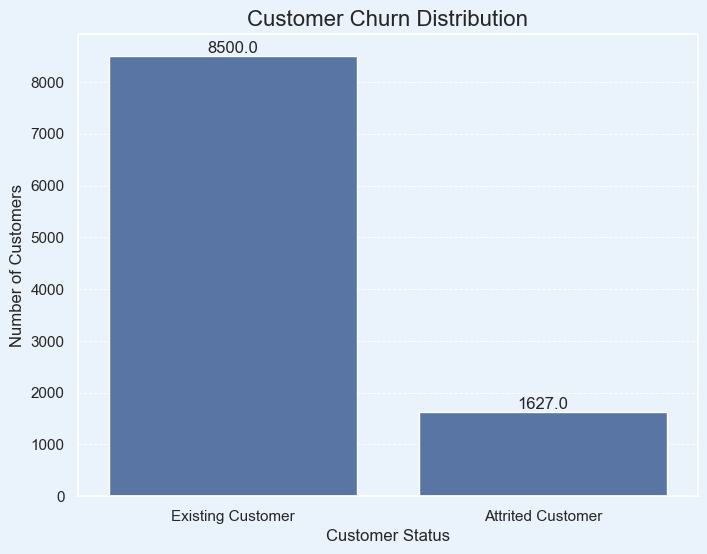

In [77]:
# Global style
sns.set_theme(style="darkgrid")

# Custom background color
plt.rcParams['axes.facecolor'] = "#eaf2fb"   
plt.rcParams['figure.facecolor'] = "#eaf2fb"

# Grid style
plt.rcParams['grid.color'] = 'white'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = 0.7
plt.figure(figsize=(8,6))
ax = sns.countplot(data=df, x="Attrition_Flag")
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title("Customer Churn Distribution", fontsize=16)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.show()


The dataset is clearly imbalanced, with far more existing customers than churned customers, which must be taken into account during model training.

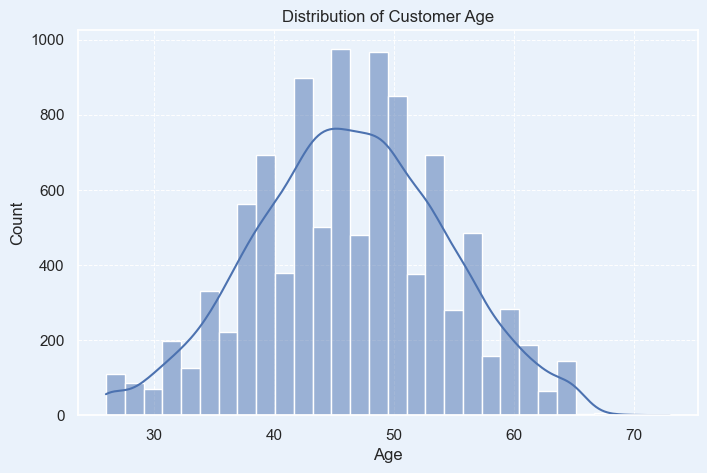

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Customer_Age'], bins=30, kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


Most customers are between 40 and 55 years old, indicating that the bank's customer base is largely composed of middle-aged individuals.

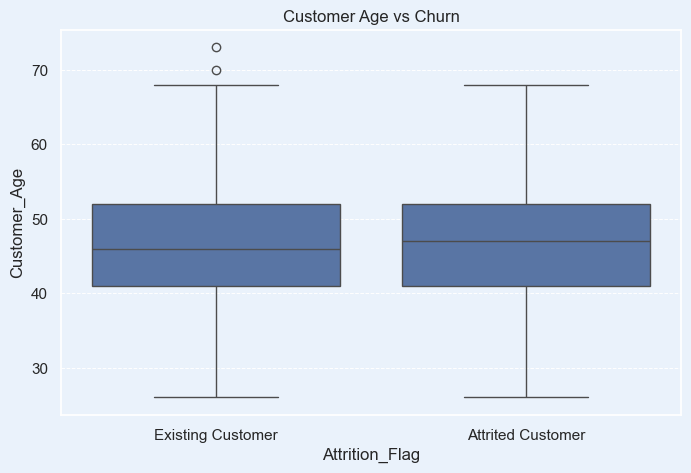

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition_Flag', y='Customer_Age', data=df)
plt.title("Customer Age vs Churn")
plt.show()


Both groups show a similar age distribution, but churned customers tend to have a slightly higher median age, suggesting that older customers may be marginally more likely to churn.

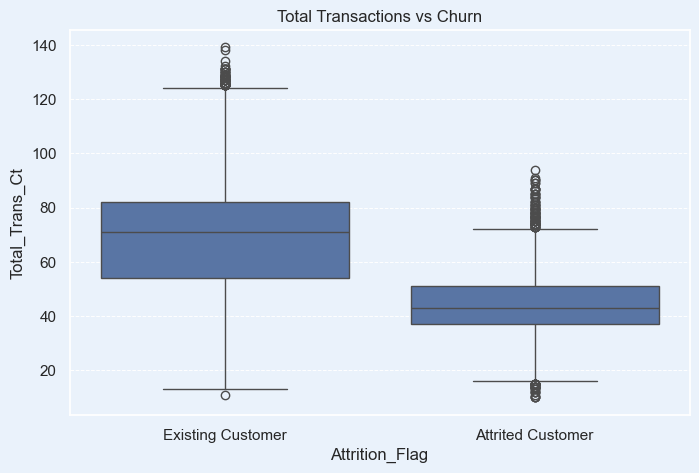

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition_Flag', y='Total_Trans_Ct', data=df)
plt.title("Total Transactions vs Churn")
plt.show()


Churned customers generally have fewer transactions than existing customers, suggesting that lower engagement with the bank may increase the likelihood of churn.

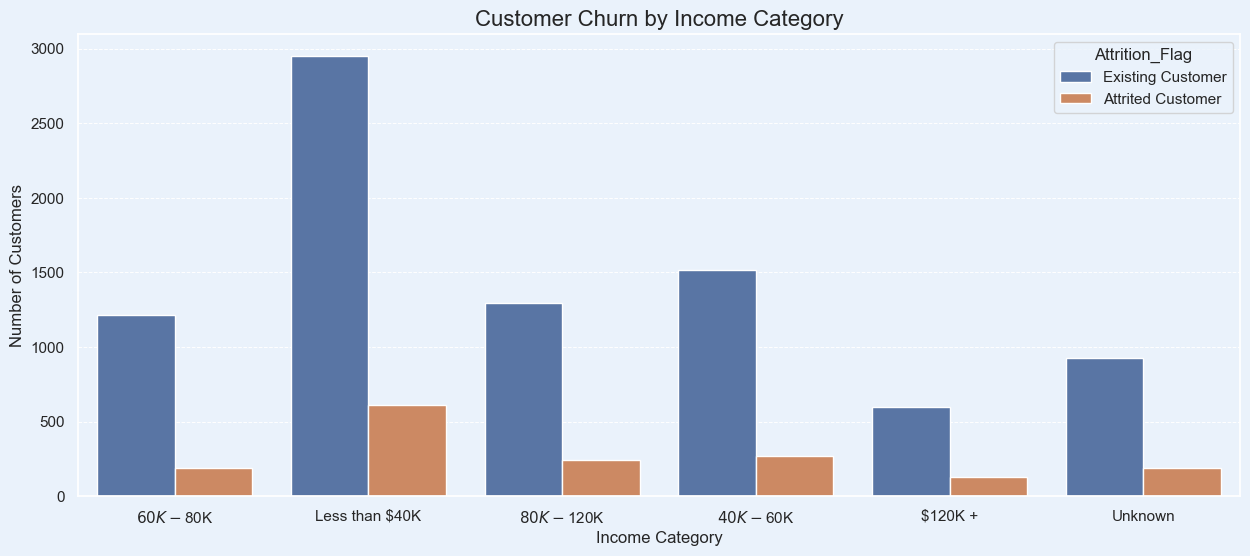

In [78]:
plt.figure(figsize=(15,6))
sns.countplot(data=df, x="Income_Category", hue="Attrition_Flag")
plt.title("Customer Churn by Income Category", fontsize=16)
plt.xlabel("Income Category")
plt.ylabel("Number of Customers")
plt.show()



Customers earning less than $40K form the largest segment and therefore show the highest number of churn cases. However, churn appears relatively consistent across income groups, suggesting that income level alone may not strongly influence customer attrition.

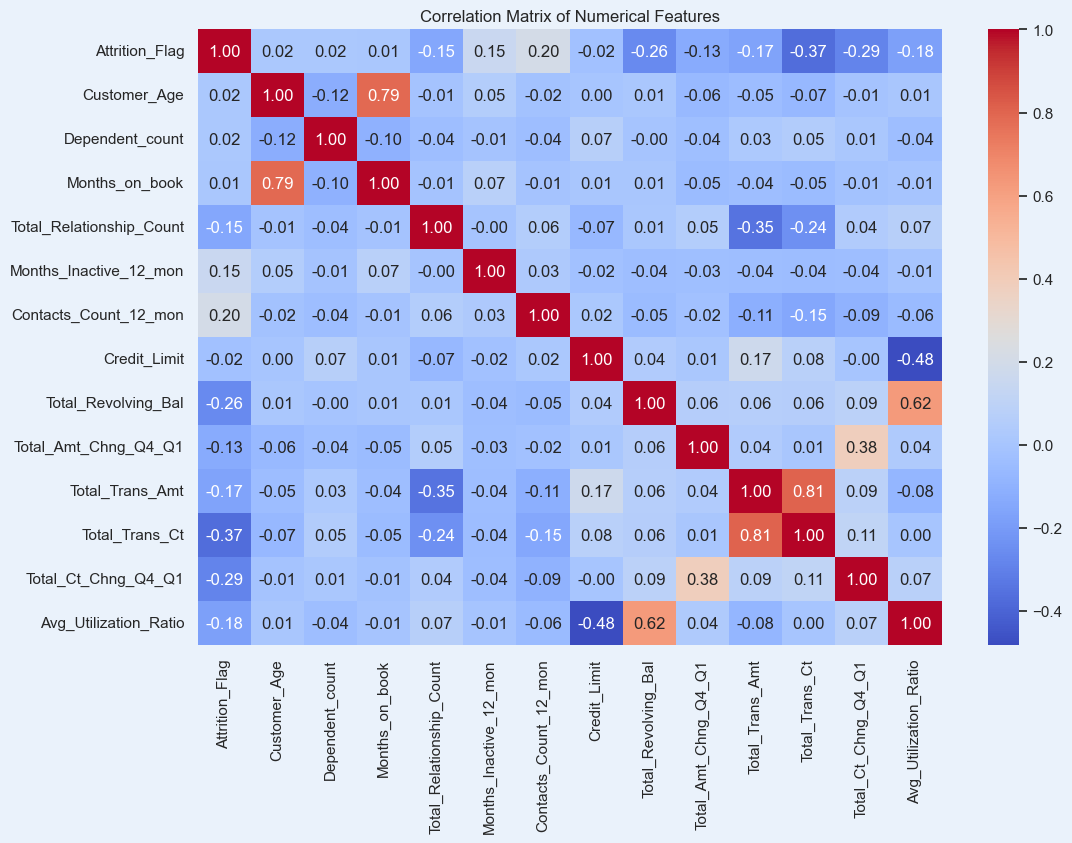

In [79]:
df_model = df.copy()
# Encode the target variable
df_model['Attrition_Flag'] = df_model['Attrition_Flag'].map({
    'Existing Customer': 0,
    'Attrited Customer': 1
})
# Select numerical features
df_model = df_model[['Attrition_Flag',
          'Customer_Age',
          'Dependent_count',
          'Months_on_book',
          'Total_Relationship_Count',
          'Months_Inactive_12_mon',
          'Contacts_Count_12_mon',
          'Credit_Limit',
          'Total_Revolving_Bal',
          'Total_Amt_Chng_Q4_Q1',
          'Total_Trans_Amt',
          'Total_Trans_Ct',
          'Total_Ct_Chng_Q4_Q1',
          'Avg_Utilization_Ratio']]

# Correlation matrix
correlation = df_model.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()



The correlation matrix highlights the relationships between the numerical features and the target variable (Attrition_Flag), as well as the relationships among the features themselves.

First, several variables show moderate correlations with the target variable. In particular, `Total_Trans_Ct` (-0.37) and `Total_Ct_Chng_Q4_Q1` (-0.29) show the strongest negative correlations with churn. This suggests that customers who perform more transactions or whose transaction activity is increasing are less likely to churn. In other words, higher engagement with the bank appears to reduce the probability of attrition.

On the other hand, `Contacts_Count_12_mon` (0.20) and `Months_Inactive_12_mon` (0.15) have positive correlations with churn. This may indicate that customers who contact the bank more frequently or remain inactive for longer periods are more likely to leave, possibly reflecting dissatisfaction or reduced engagement.

Among the independent variables, a strong positive correlation is observed between `Customer_Age` and `Months_on_book` (0.79), which is expected since older customers tend to have been with the bank for a longer period.

Another strong correlation appears between `Total_Trans_Amt` and `Total_Trans_Ct` (0.81), indicating that customers who make more transactions also tend to generate higher total transaction amounts.

Additionally, `Total_Revolving_Bal` and `Avg_Utilization_Ratio` (0.62) are positively correlated, while `Credit_Limit` and `Avg_Utilization_Ratio` (-0.48) are negatively correlated. This suggests that customers with higher credit limits tend to use a smaller proportion of their available credit.

Overall, the matrix indicates that customer activity and engagement variables, such as transaction behavior and inactivity periods, may play an important role in explaining customer churn.

In [ ]:
# Display unique categories for each categorical feature
pd.set_option('display.max_colwidth', None)
cat = []
for col_name in df.select_dtypes(include=['object','string']).columns:
    categories_list = df[col_name].value_counts().index.to_list()
    cat.append([col_name, categories_list])
pd.DataFrame(cat, columns=["Column Name", "Classes"])\
  .set_index("Column Name")\
  .rename_axis(None)

,Classes
Attrition_Flag,"[Existing Customer, Attrited Customer]"
Gender,"[F, M]"
Education_Level,"[Graduate, High School, Unknown, Uneducated, College, Post-Graduate, Doctorate]"
Marital_Status,"[Married, Single, Unknown, Divorced]"
Income_Category,"[Less than $40K, $40K - $60K, $80K - $120K, $60K - $80K, Unknown, $120K +]"
Card_Category,"[Blue, Silver, Gold, Platinum]"




The dataset contains several categorical variables describing customer demographics and credit card characteristics. Some variables are binary (e.g., Gender and Attrition_Flag), while others have multiple categories such as Education_Level, Income_Category, and Card_Category.

These categorical features will require appropriate encoding techniques before being used in machine learning models.

## Feature Engineering


In [80]:
df_model = df.copy()
# Drop useless identifier
df_model = df_model.drop(columns=['CLIENTNUM'])
# Encode binary variables
## Target variable
df_model['Attrition_Flag'] = df_model['Attrition_Flag'].map({'Existing Customer': 0,'Attrited Customer': 1})
## Gender
df_model['Gender'] = df_model['Gender'].map({'F': 0,'M': 1})
# categorical variables
categorical_cols = ['Education_Level','Marital_Status','Income_Category','Card_Category']
# One-Hot Encoding
df_model = pd.get_dummies(df_model,columns=categorical_cols,drop_first=True,dtype=int)
# Separate features and target
X = df_model.drop(columns=['Attrition_Flag'])
y = df_model   ['Attrition_Flag']
# Check final result
print("Feature engineering completed.")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nEncoded dataset preview:")
display(df_model.head())
print("\nRemaining missing values:")
print(df_model.isnull().sum().sum())

Feature engineering completed.
X shape: (10127, 32)
y shape: (10127,)

Encoded dataset preview:


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,1,3,39,5,1,3,12691.0,777,...,0,0,0,1,0,0,0,0,0,0
1,0,49,0,5,44,6,1,2,8256.0,864,...,1,0,0,0,0,1,0,0,0,0
2,0,51,1,3,36,4,1,0,3418.0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,40,0,4,34,3,4,1,3313.0,2517,...,0,1,0,0,0,1,0,0,0,0
4,0,40,1,3,21,5,1,0,4716.0,0,...,0,0,0,1,0,0,0,0,0,0



Remaining missing values:
0


## Machine Learning 

### 1. Logistic Regression 

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l1', 'logreg__solver': 'liblinear'}

Best Cross-Validation Recall:
0.8663807839669909

Test Accuracy:
0.8440276406712734

Test ROC-AUC:
0.9151720707276263

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90      1701
           1       0.51      0.82      0.63       325

    accuracy                           0.84      2026
   macro avg       0.73      0.83      0.76      2026
weighted avg       0.89      0.84      0.86      2026



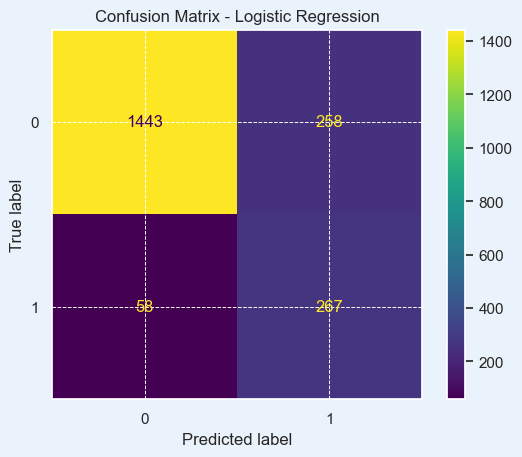

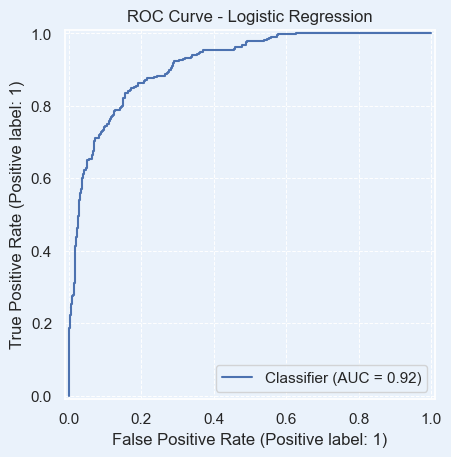

In [81]:
# 1. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42, stratify=y)
# 2. Pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(random_state=42, max_iter=5000))
])
# 3. Hyperparameter Grid
param_grid = {
    'logreg__C': [0.01, 0.1, 1, 10, 100],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__solver': ['liblinear'],
    'logreg__class_weight': [None, 'balanced']
}
# 4. Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='recall',   # important for churn detection
    cv=cv,
    n_jobs=-1,
    verbose=1
)
# 5. Train Best Model
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
# 6. Predictions
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]
# 7. Results
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest Cross-Validation Recall:")
print(grid_search.best_score_)
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))
print("\nTest ROC-AUC:")
print(roc_auc_score(y_test, y_prob))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# 8. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()
# 9. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - Logistic Regression")
plt.show()

### Logistic Regression Results

The optimized logistic regression model achieved strong predictive performance. The best hyperparameters included an L1 regularization with a relatively small C value, which helps prevent overfitting while performing implicit feature selection.

The model achieved a test accuracy of 84.4% and an ROC-AUC score of 0.91, indicating excellent discrimination between churned and non-churned customers.

Most importantly, the model reached a recall of 0.82 for the churn class, meaning that it successfully identifies a large proportion of customers who are likely to leave the bank. This is particularly valuable for churn management, where detecting at-risk customers is often more important than overall accuracy.

The confusion matrix shows that only 58 churned customers were missed by the model, while most churn cases were correctly identified. Although some false positives occur, this is acceptable in a business context since preventive retention actions can still be applied to those customers.

Overall, the logistic regression model provides a strong baseline for predicting customer churn and offers meaningful insights for proactive customer retention strategies.

## Feature Importance

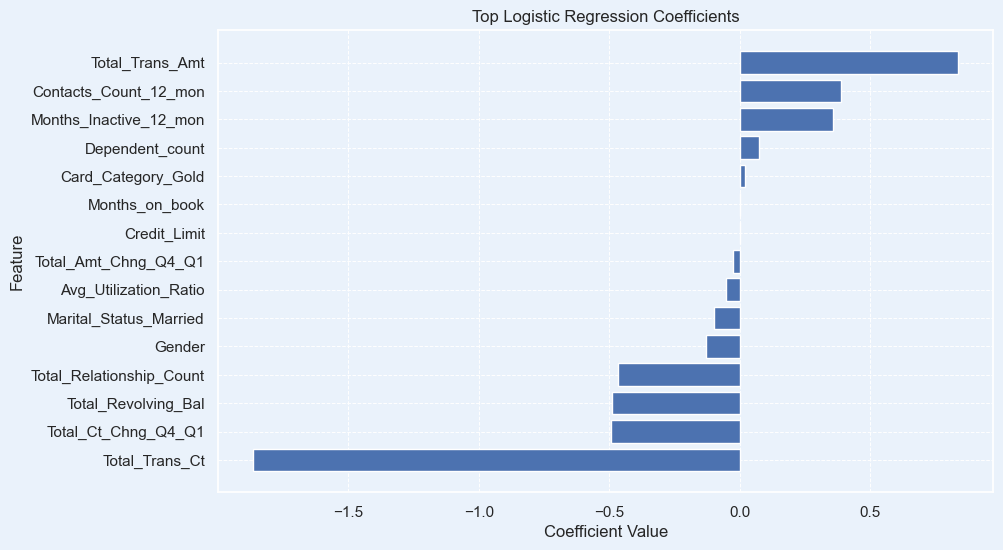

In [82]:
top_coef = coef_df.head(15).sort_values(by='Coefficient')

plt.figure(figsize=(10,6))
plt.barh(top_coef['Feature'], top_coef['Coefficient'])
plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.show()

## Random Forest

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 600}
Best Cross-Validation Recall: 0.8825051576775713

Test Accuracy: 0.9437314906219151
Test ROC-AUC: 0.9804856871523538

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1701
           1       0.80      0.86      0.83       325

    accuracy                           0.94      2026
   macro avg       0.89      0.91      0.90      2026
weighted avg       0.95      0.94      0.94      2026



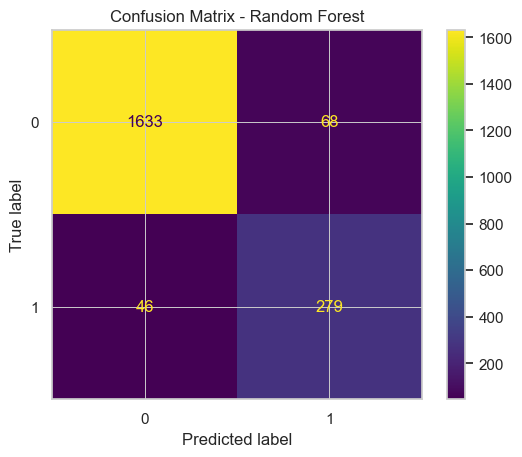

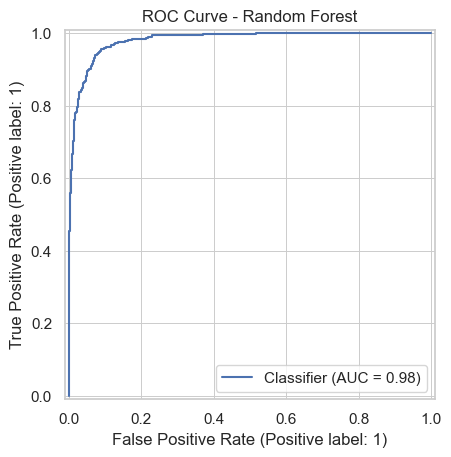

In [ ]:
# Pipeline for Random Forest
rf_pipeline = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])
# Hyperparameter grid
param_grid_rf = {
    'model__n_estimators': [200, 400, 600],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': [None, 'balanced']
}
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=cv,
    scoring='recall',   
    n_jobs=-1,
    verbose=1
)
# Training
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
# Predictions
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
# Evaluation
print("Best Parameters:", rf_grid.best_params_)
print("Best Cross-Validation Recall:", rf_grid.best_score_)

print("\nTest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()
# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_rf)
plt.title("ROC Curve - Random Forest")
plt.show()

### Random Forest Results

The Random Forest classifier significantly improved performance compared to logistic regression. The model achieved a test accuracy of 94.3% and an ROC-AUC score of 0.98, indicating excellent discrimination between churned and non-churned customers.

The recall for the churn class reached 0.86, meaning that the model successfully identifies the majority of customers who are likely to leave the bank. This improvement is particularly important for churn management, where detecting at-risk customers is a key objective.

The confusion matrix shows that only 46 churned customers were missed by the model, while most churn cases were correctly identified. Additionally, the number of false positives is relatively low, making the model suitable for proactive retention strategies.

Overall, Random Forest provides a substantial performance improvement and appears to be a strong candidate for the final churn prediction model.

## Feature Importance

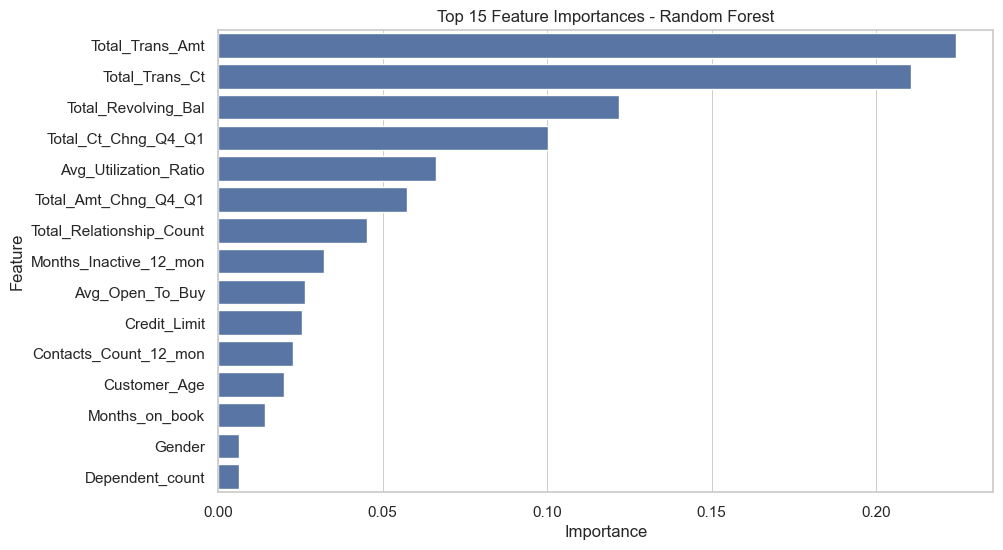

,Feature,Importance
11,Total_Trans_Amt,0.224292
12,Total_Trans_Ct,0.210482
8,Total_Revolving_Bal,0.121854
13,Total_Ct_Chng_Q4_Q1,0.100374
14,Avg_Utilization_Ratio,0.066137
10,Total_Amt_Chng_Q4_Q1,0.057315
4,Total_Relationship_Count,0.045208
5,Months_Inactive_12_mon,0.032241
9,Avg_Open_To_Buy,0.026269
7,Credit_Limit,0.025495


In [ ]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.named_steps['model'].feature_importances_
}).sort_values(by='Importance', ascending=False)

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=top_features, x='Importance', y='Feature')
plt.title("Top 15 Feature Importances - Random Forest")
plt.show()

feature_importance.head(10)

## XGBoost Classifier

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best Cross-Validation Recall: 0.9470144414972002

Test Accuracy: 0.9575518262586377
Test ROC-AUC: 0.9908922353366797

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      1701
           1       0.83      0.92      0.87       325

    accuracy                           0.96      2026
   macro avg       0.91      0.94      0.92      2026
weighted avg       0.96      0.96      0.96      2026



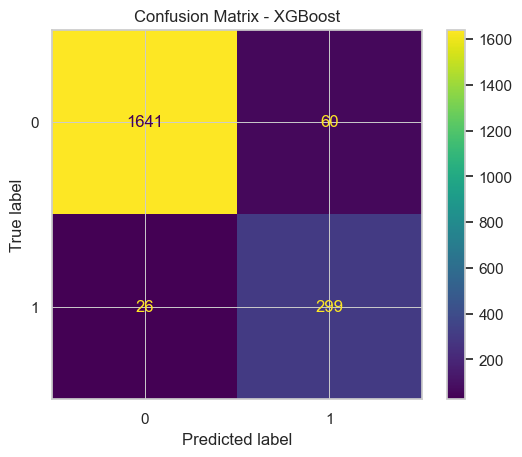

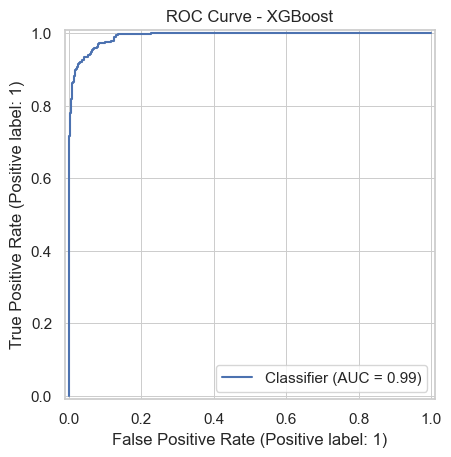

In [ ]:
# 1. Compute class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
# 2. Base model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight
)
# 3. Hyperparameter space
param_dist_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10]
}
# 4. Cross-validation 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# 5. Randomized Search
xgb_random = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring='recall',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
# 6. Fit model
xgb_random.fit(X_train, y_train)
best_xgb = xgb_random.best_estimator_
# 7. Predictions
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]
# 8. Evaluation
print("Best Parameters:", xgb_random.best_params_)
print("Best Cross-Validation Recall:", xgb_random.best_score_)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))
# 9. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("Confusion Matrix - XGBoost")
plt.show()
# 10. ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob_xgb)
plt.title("ROC Curve - XGBoost")
plt.show()

### XGBoost Model Performance

XGBoost achieved the best performance among all tested models. The classifier reached an accuracy of 95.7% and an ROC-AUC score of 0.99, indicating excellent discrimination between churned and non-churned customers.

The model achieved a recall of 0.92 for the churn class, meaning that it successfully identifies the vast majority of customers who are likely to leave. This is particularly important for churn prediction, where missing at-risk customers can lead to significant revenue loss.

The confusion matrix shows that only 26 churned customers were missed by the model, which is a significant improvement compared to the previous models.

Overall, XGBoost provides the strongest predictive performance and is selected as the final model for customer churn prediction.

## Feature Importance

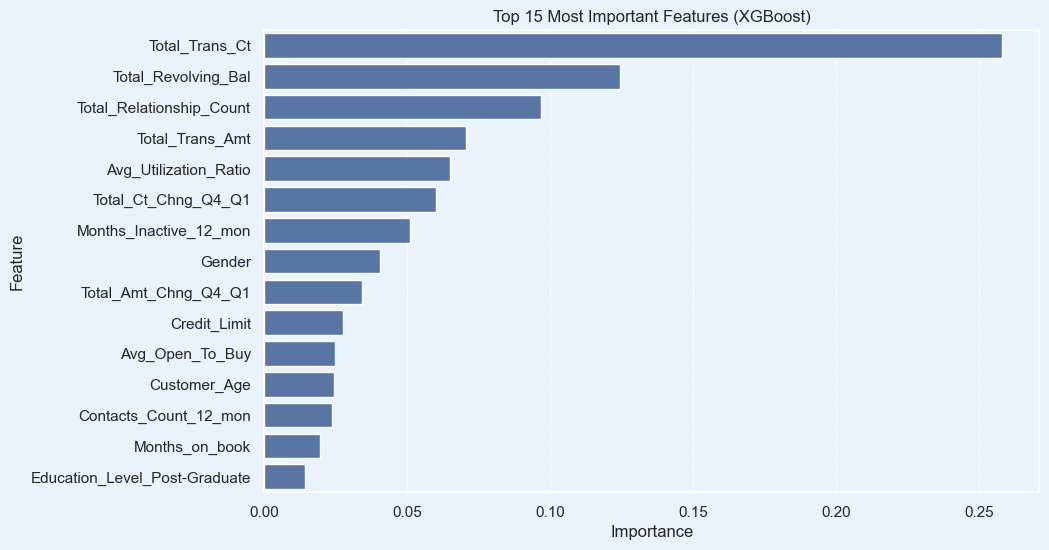

,Feature,Importance
12,Total_Trans_Ct,0.258053
8,Total_Revolving_Bal,0.124243
4,Total_Relationship_Count,0.096726
11,Total_Trans_Amt,0.070447
14,Avg_Utilization_Ratio,0.064793
13,Total_Ct_Chng_Q4_Q1,0.060074
5,Months_Inactive_12_mon,0.050787
1,Gender,0.040415
10,Total_Amt_Chng_Q4_Q1,0.034290
7,Credit_Limit,0.027429


In [83]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})
importances = importances.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importances.head(15), x="Importance", y="Feature")
plt.title("Top 15 Most Important Features (XGBoost)")
plt.show()

importances.head(10)

## Machine Learning Model Comparison

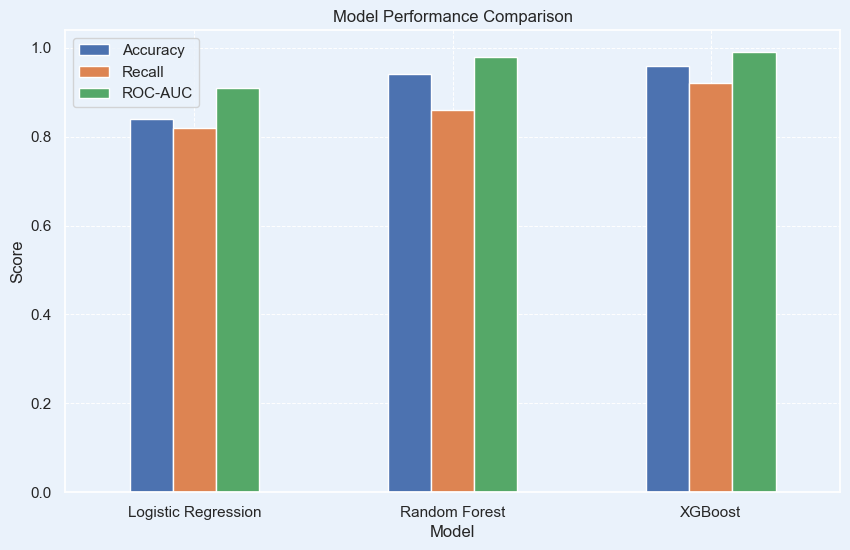

In [84]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]

accuracy = [0.84, 0.94, 0.96]
recall = [0.82, 0.86, 0.92]
roc_auc = [0.91, 0.98, 0.99]

comparison = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracy,
    "Recall": recall,
    "ROC-AUC": roc_auc
})
comparison.set_index("Model").plot(kind="bar", figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Conclusion

This project aimed to develop a machine learning model capable of predicting customer churn in a banking environment. Customer churn represents a major challenge for financial institutions, as retaining existing customers is generally more cost-effective than acquiring new ones. Therefore, identifying customers who are at risk of leaving the bank can enable the implementation of proactive retention strategies.

**This project demonstrates how machine learning can be used to proactively identify customers at risk of leaving and support data-driven retention strategies in the banking sector.**

The analysis began with an exploratory data analysis to understand the structure of the dataset and identify key patterns related to customer attrition. Several behavioral indicators, particularly those related to customer engagement and transaction activity, showed strong relationships with churn. Variables such as the number of transactions, transaction amount, inactivity periods, and customer-bank interactions appeared to be important drivers of customer behavior.

**The exploratory analysis revealed that customer engagement variables such as transaction activity and account usage play a critical role in understanding and predicting customer churn.**

To build a robust predictive system, three different machine learning models were evaluated: Logistic Regression, Random Forest, and XGBoost. Each model represents a different level of complexity and predictive capability.

Logistic Regression was first implemented as a baseline model. This model has the advantage of being highly interpretable, allowing us to understand the direction and magnitude of the influence of each variable on the probability of churn. While the model performed reasonably well, achieving solid predictive performance, it remains limited in its ability to capture complex nonlinear relationships between variables.

Random Forest was then introduced as a more advanced ensemble learning method. By combining multiple decision trees, Random Forest can model nonlinear interactions and complex patterns in the data. This model significantly improved predictive performance compared to Logistic Regression, achieving higher accuracy, better recall for churn detection, and a stronger ROC-AUC score. Additionally, Random Forest provided valuable insights through feature importance analysis.

Finally, XGBoost was applied as the third and most advanced model. XGBoost is a gradient boosting algorithm that iteratively improves model performance by focusing on previously misclassified observations. This approach allows it to capture subtle patterns and interactions within the dataset.

**Among the three models tested, XGBoost delivered the best overall performance, achieving the highest accuracy, the highest recall for churn detection, and the strongest ROC-AUC score.**

From a business perspective, the most critical metric is the recall of the churn class, as failing to detect customers who are about to leave can lead to direct revenue loss.

**XGBoost demonstrated the strongest ability to correctly identify customers at risk of churn while minimizing missed churn cases, making it the most effective model for proactive retention strategies.**

Moreover, the model produced fewer missed churn cases compared to the other algorithms, which significantly increases its practical value for business applications.

**Based on these results, XGBoost was selected as the final model for customer churn prediction.**

Its superior performance across multiple evaluation metrics indicates that it is the most suitable model for this task. The model can effectively support decision-making processes by helping banks identify at-risk customers and implement targeted interventions, such as personalized offers, loyalty programs, or proactive customer support.

**This predictive system can help financial institutions shift from reactive customer management to proactive churn prevention strategies.**

In summary, this project demonstrates how machine learning techniques can be leveraged to transform customer data into actionable insights. By combining exploratory analysis, feature engineering, and advanced predictive modeling, it is possible to build a reliable system capable of identifying churn risk and supporting customer retention strategies.

Future improvements could include the integration of model explainability techniques such as SHAP values, the calibration of decision thresholds based on business costs, and the deployment of the model within a real-time decision support system.

<hr>

<div style="display:flex; align-items:center; gap:10px; opacity:0.8;">

<img src="https://github.githubassets.com/images/modules/logos_page/GitHub-Mark.png" width="32">

<span style="font-size:15px;">
Powered by <strong>Zougagh Ayoub</strong>
</span>

</div>